# Classical Time Series Forecasting: ARIMA, SARIMA, SARIMAX, and Holt-Winters

This notebook is an educational, reproducible walkthrough of four classical
time series forecasting methods implemented in `statsmodels`:

- **ARIMA** — AutoRegressive Integrated Moving Average
- **SARIMA** — Seasonal ARIMA
- **SARIMAX** — Seasonal ARIMA with eXogenous regressors
- **Holt-Winters / Exponential Smoothing**

Each method is explained conceptually, demonstrated on a real, built-in dataset
with several different parameter settings, evaluated with standard error
metrics (MAE, RMSE, MAPE), and finally compared side by side.

**Contents**

1. Introduction
2. Data loading and preprocessing
3. Utility functions
4. ARIMA model
5. SARIMA model
6. SARIMAX model with exogenous variables
7. Holt-Winters / Exponential Smoothing
8. Model comparison
9. Conclusions

> **Note on structure.** The helper functions discussed conceptually in
> Section 3 ("Utility functions") are actually *defined* in the **Setup**
> code cell immediately below, right after the imports. This is so that
> they are available to every later modeling section -- the notebook is
> meant to run top to bottom without errors, so the functions must exist
> before they are first called. Section 3 then walks through what each
> function does and shows its source code for reference.


In [1]:
# Uncomment the line below if any of these packages are missing in your environment.
# !pip install pandas numpy matplotlib statsmodels scikit-learn


In [2]:
# --- Setup: imports and helper functions used throughout the notebook ---

import warnings
import inspect

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# statsmodels: built-in datasets and forecasting models
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# scikit-learn: evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

# Model fitting can emit convergence/optimizer warnings that are not
# actionable in a teaching notebook; silence them so the output stays
# focused on results. Errors are NOT silenced.
warnings.filterwarnings("ignore")

# A reasonable default figure size for every plot in the notebook.
plt.rcParams["figure.figsize"] = (10, 4)

# This list accumulates one row of metrics per fitted model. Section 8
# ("Model comparison") turns it into a single summary table at the end.
results = []


def evaluate_forecast(y_true, y_pred):
    """Return MAE, RMSE and MAPE (in %) between true and forecast values."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}


def print_metrics(y_true, y_pred, model_name):
    """Print MAE, RMSE and MAPE for one forecast in a single readable line."""
    metrics = evaluate_forecast(y_true, y_pred)
    print(
        f"{model_name:38s} MAE={metrics['MAE']:.3f}  "
        f"RMSE={metrics['RMSE']:.3f}  MAPE={metrics['MAPE']:.2f}%"
    )
    return metrics


def plot_forecast(train, test, forecast, title, n_train_show=None):
    """Plot recent training history, held-out test values, and the forecast.

    n_train_show limits how many of the most recent training points are
    shown, which keeps plots readable for long series (e.g. monthly data
    spanning decades).
    """
    history = train if n_train_show is None else train.iloc[-n_train_show:]
    plt.figure()
    plt.plot(history.index, history.values, label="Train")
    plt.plot(test.index, test.values, label="Test (actual)", color="black")
    plt.plot(
        test.index, np.asarray(forecast), label="Forecast",
        color="red", linestyle="--",
    )
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.show()


def record_result(model_name, params, dataset, y_true, y_pred):
    """Evaluate a forecast and store it as one row of the comparison table."""
    metrics = evaluate_forecast(y_true, y_pred)
    results.append({
        "Dataset": dataset,
        "Model": model_name,
        "Parameters": params,
        "MAE": round(metrics["MAE"], 3),
        "RMSE": round(metrics["RMSE"], 3),
        "MAPE (%)": round(metrics["MAPE"], 2),
    })
    return metrics


## 1. Introduction

**Time series forecasting** is the task of predicting future values of a
variable that is observed sequentially over time (e.g. monthly CO2
concentration, quarterly GDP, daily sales). Unlike standard regression on
independent observations, time series data points are usually correlated
with their own past values, which is exactly the structure that the
classical models in this notebook are built to exploit.

ARIMA-family models (ARIMA, SARIMA, SARIMAX) and exponential smoothing
(Holt-Winters) remain widely used because they are:

- **Interpretable** — each parameter has a clear statistical meaning.
- **Data-efficient** — they can produce good forecasts from a few dozen to a
  few hundred observations, unlike many machine-learning models.
- **Strong baselines** — even in the era of deep learning, these models are
  the standard benchmark that more complex methods must beat.

### Key vocabulary

- **Trend** — a long-term increase or decrease in the level of the series
  (e.g. the steady rise in atmospheric CO2 since 1958).
- **Seasonality** — a pattern that repeats at a fixed, known frequency (e.g.
  a yearly cycle in monthly data, period = 12).
- **Stationarity** — a series is (weakly) stationary if its mean, variance,
  and autocorrelation structure do not change over time. Many classical
  models assume stationarity, which is why **differencing** (the "I" in
  ARIMA) is used to remove trend/level changes before modeling.
- **Autocorrelation** — the correlation of a series with a lagged version of
  itself. Significant autocorrelation at certain lags is exactly what
  AR and MA terms are designed to capture, and is visualized with ACF/PACF
  plots.
- **Exogenous variables** — external predictor series (not the target
  itself) that may help explain or forecast the target, e.g. forecasting
  GDP using consumption or interest-rate data. SARIMAX is the model in this
  notebook that supports them.
- **Forecasting horizon** — the number of future time steps to be
  predicted. A short horizon (e.g. 1 step ahead) is generally easier than a
  long horizon (e.g. 24 steps ahead), because uncertainty compounds with
  distance into the future.

The rest of the notebook loads three real datasets, defines shared helper
functions, and then works through ARIMA, SARIMA, SARIMAX, and Holt-Winters
in turn, each with several parameter settings, plots, and error metrics.


## 2. Data loading and preprocessing

We use three built-in datasets from `statsmodels.datasets`, chosen so that
each highlights a different modeling situation:

| Dataset | Frequency | Used for | Why |
|---|---|---|---|
| `nile` | Annual | ARIMA | Trend/level shifts, **no** seasonality |
| `co2` | Monthly (resampled) | SARIMA, Holt-Winters | Clear trend **and** yearly seasonality |
| `macrodata` | Quarterly | SARIMAX | Target variable **plus** exogenous regressors |

For each dataset we show the first rows, build a proper `DatetimeIndex`,
plot the series, and split it into a train and a test set (the test set is
always the most recent observations, which is the standard approach for
time series — we never shuffle time series data).


### 2.1 Nile river annual flow volume (for ARIMA)

The Nile dataset contains the annual flow volume of the river Nile at
Aswan from 1871 to 1970. It famously contains a structural level shift
around 1898 (after the construction of a dam), but no seasonal pattern --
which makes it a good, simple illustration for **non-seasonal ARIMA**.


In [3]:
# Load the Nile dataset and build a proper annual DatetimeIndex
nile_raw = sm.datasets.nile.load_pandas().data
nile_raw.index = pd.date_range(start=str(int(nile_raw["year"].iloc[0])),
                                periods=len(nile_raw), freq="YS")
nile = nile_raw["volume"]
nile.name = "volume"

print(nile.head())
print("\nNumber of observations:", len(nile))


1871-01-01    1120.0
1872-01-01    1160.0
1873-01-01     963.0
1874-01-01    1210.0
1875-01-01    1160.0
Freq: YS-JAN, Name: volume, dtype: float64

Number of observations: 100


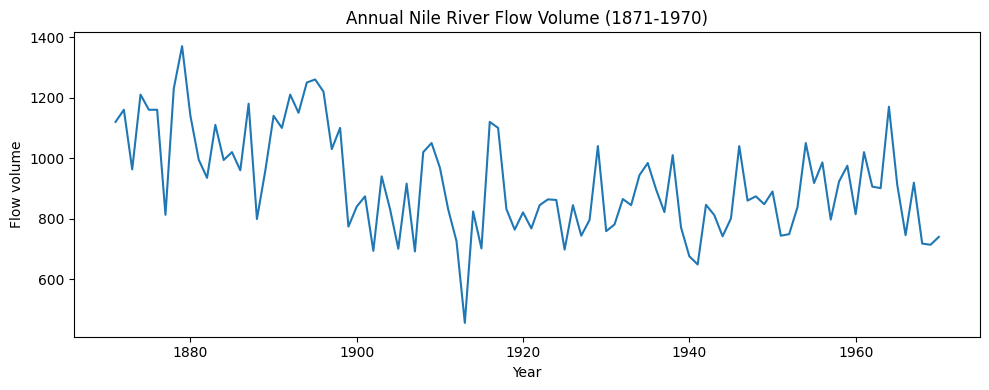

In [4]:
# Plot the full series
plt.figure()
plt.plot(nile.index, nile.values)
plt.title("Annual Nile River Flow Volume (1871-1970)")
plt.xlabel("Year")
plt.ylabel("Flow volume")
plt.tight_layout()
plt.show()


In [5]:
# Quick stationarity check with the Augmented Dickey-Fuller (ADF) test.
# H0: the series has a unit root (is non-stationary).
adf_stat, adf_pvalue, *_ = adfuller(nile)
print(f"ADF statistic: {adf_stat:.3f}")
print(f"ADF p-value:   {adf_pvalue:.4f}")
if adf_pvalue < 0.05:
    print("=> Reject H0: the raw series does not show strong evidence of a unit root.")
else:
    print("=> Fail to reject H0: the raw series looks non-stationary; differencing is recommended.")
# Note: even when the ADF test does not strongly reject stationarity, the
# visible 1898 level shift is the kind of low-frequency structure that
# first-order differencing (d=1) helps to remove, which is why d=1 is used
# in the ARIMA examples below.


ADF statistic: -4.049
ADF p-value:   0.0012
=> Reject H0: the raw series does not show strong evidence of a unit root.


In [6]:
# Train/test split: hold out the last 12 years as the test set
nile_train, nile_test = nile.iloc[:-12], nile.iloc[-12:]
print("Train period:", nile_train.index[0].date(), "to", nile_train.index[-1].date(),
      f"({len(nile_train)} obs)")
print("Test period: ", nile_test.index[0].date(), "to", nile_test.index[-1].date(),
      f"({len(nile_test)} obs)")


Train period: 1871-01-01 to 1958-01-01 (88 obs)
Test period:  1959-01-01 to 1970-01-01 (12 obs)


### 2.2 Atmospheric CO2 concentration, monthly (for SARIMA and Holt-Winters)

The `co2` dataset contains weekly atmospheric CO2 concentration
measurements from the Mauna Loa Observatory (1958-2001). We resample it to
monthly averages and linearly interpolate the handful of missing weeks.
The resulting series has a strong upward trend (rising CO2 levels) and a
clear annual seasonal cycle (period = 12) caused by the Northern
Hemisphere growing season -- this is the AirPassengers-style monthly,
trend-plus-seasonality series recommended for demonstrating SARIMA.


In [7]:
# Load the CO2 dataset (already has a DatetimeIndex) and resample to monthly means
co2_weekly = sm.datasets.co2.load_pandas().data["co2"]
co2_monthly = co2_weekly.resample("MS").mean()

print("Missing months before interpolation:", co2_monthly.isna().sum())
co2_monthly = co2_monthly.interpolate()
co2_monthly.name = "co2"

print(co2_monthly.head())
print("\nNumber of observations:", len(co2_monthly))


Missing months before interpolation: 5
1958-03-01    316.100000
1958-04-01    317.200000
1958-05-01    317.433333
1958-06-01    316.529167
1958-07-01    315.625000
Freq: MS, Name: co2, dtype: float64

Number of observations: 526


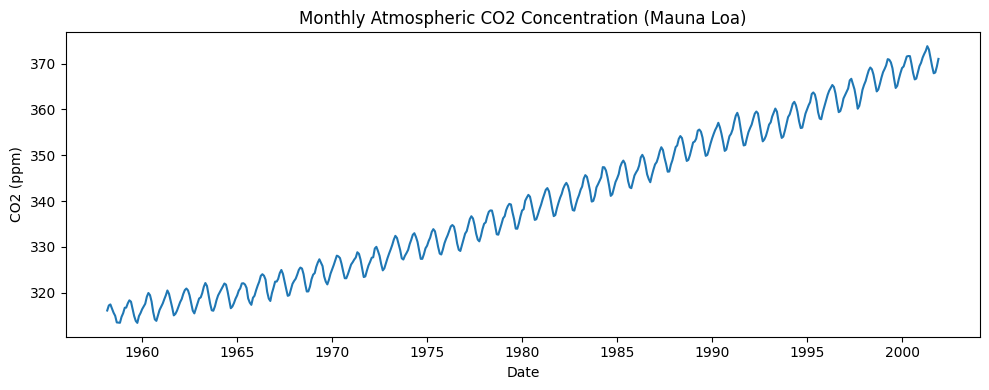

In [8]:
# Plot the full monthly series
plt.figure()
plt.plot(co2_monthly.index, co2_monthly.values)
plt.title("Monthly Atmospheric CO2 Concentration (Mauna Loa)")
plt.xlabel("Date")
plt.ylabel("CO2 (ppm)")
plt.tight_layout()
plt.show()


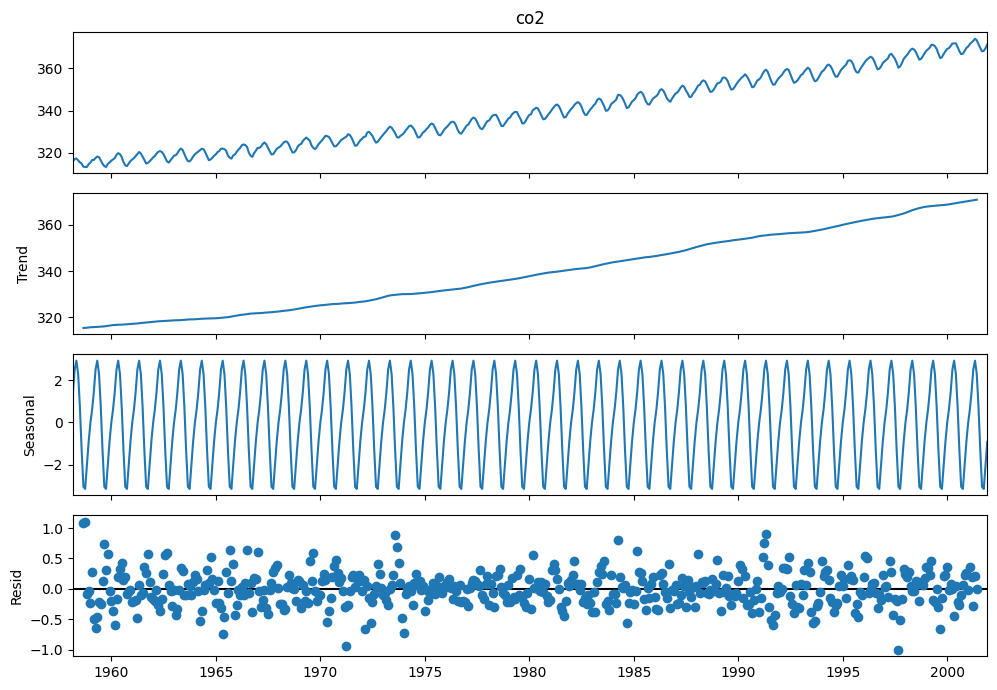

In [9]:
# Seasonal decomposition makes the trend and the yearly seasonal cycle explicit
decomposition = seasonal_decompose(co2_monthly, model="additive", period=12)
fig = decomposition.plot()
fig.set_size_inches(10, 7)
plt.tight_layout()
plt.show()


In [10]:
# Train/test split: hold out the last 24 months (2 years) as the test set
co2_train, co2_test = co2_monthly.iloc[:-24], co2_monthly.iloc[-24:]
print("Train period:", co2_train.index[0].date(), "to", co2_train.index[-1].date(),
      f"({len(co2_train)} obs)")
print("Test period: ", co2_test.index[0].date(), "to", co2_test.index[-1].date(),
      f"({len(co2_test)} obs)")


Train period: 1958-03-01 to 1999-12-01 (502 obs)
Test period:  2000-01-01 to 2001-12-01 (24 obs)


### 2.3 US macroeconomic data, quarterly (for SARIMAX)

The `macrodata` dataset contains quarterly US macroeconomic indicators from
1959 to 2009. We will forecast **real GDP** (`realgdp`) using two
**exogenous** regressors: real personal consumption (`realcons`) and the
M1 money supply (`m1`). This is a natural fit for SARIMAX, since GDP is
strongly related to consumption and the money supply, and (in a real
forecasting scenario) projected or planned values of such indicators are
often available before GDP itself is known.


In [11]:
# Load macrodata and build a proper quarterly DatetimeIndex
macro = sm.datasets.macrodata.load_pandas().data
macro.index = pd.date_range(start="1959-01-01", periods=len(macro), freq="QS")

print(macro[["realgdp", "realcons", "m1"]].head())
print("\nNumber of observations:", len(macro))


             realgdp  realcons     m1
1959-01-01  2710.349    1707.4  139.7
1959-04-01  2778.801    1733.7  141.7
1959-07-01  2775.488    1751.8  140.5
1959-10-01  2785.204    1753.7  140.0
1960-01-01  2847.699    1770.5  139.6

Number of observations: 203


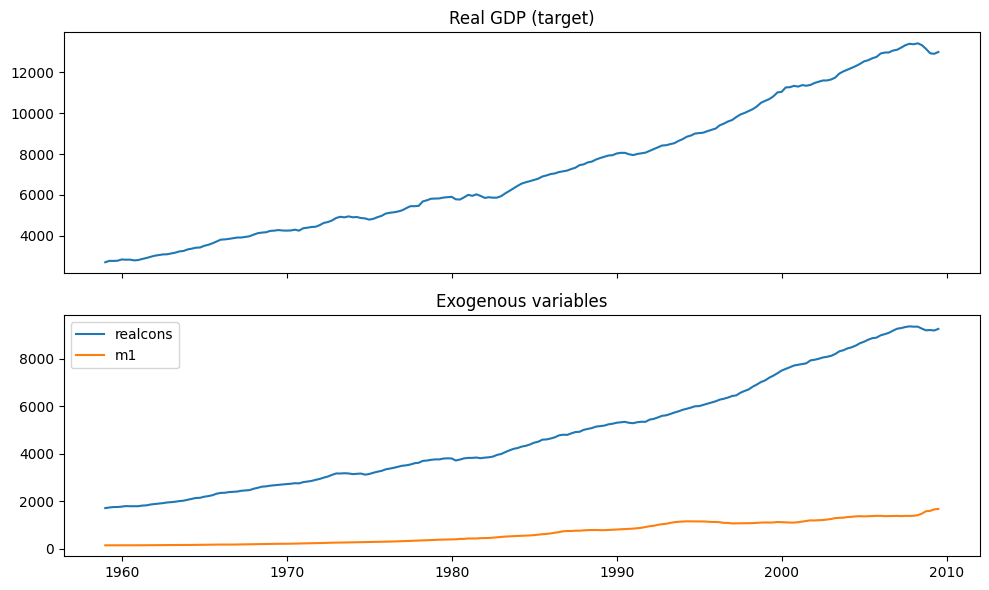

In [12]:
# Define target and exogenous variables
target = macro["realgdp"]
exog = macro[["realcons", "m1"]]

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
axes[0].plot(target.index, target.values, color="tab:blue")
axes[0].set_title("Real GDP (target)")
axes[1].plot(exog.index, exog["realcons"], label="realcons")
axes[1].plot(exog.index, exog["m1"], label="m1")
axes[1].set_title("Exogenous variables")
axes[1].legend()
plt.tight_layout()
plt.show()


In [13]:
# Train/test split: hold out the last 8 quarters (2 years) for both target and exogenous data
macro_train_y, macro_test_y = target.iloc[:-8], target.iloc[-8:]
macro_train_x, macro_test_x = exog.iloc[:-8], exog.iloc[-8:]

print("Train period:", macro_train_y.index[0].date(), "to", macro_train_y.index[-1].date(),
      f"({len(macro_train_y)} obs)")
print("Test period: ", macro_test_y.index[0].date(), "to", macro_test_y.index[-1].date(),
      f"({len(macro_test_y)} obs)")


Train period: 1959-01-01 to 2007-07-01 (195 obs)
Test period:  2007-10-01 to 2009-07-01 (8 obs)


## 3. Utility functions

To keep the modeling sections short and consistent, four small helper
functions are used throughout the notebook (already defined in the Setup
cell above, right after the imports):

- **`evaluate_forecast(y_true, y_pred)`** — computes MAE, RMSE, and MAPE
  (%) and returns them as a dictionary.
- **`print_metrics(y_true, y_pred, model_name)`** — calls
  `evaluate_forecast` and prints a single formatted line, useful for
  quickly comparing models as they are fit.
- **`plot_forecast(train, test, forecast, title, n_train_show=None)`** —
  draws the training history, the held-out test values, and the forecast
  on one chart.
- **`record_result(model_name, params, dataset, y_true, y_pred)`** —
  evaluates a forecast and appends one row (model, parameters, dataset,
  MAE, RMSE, MAPE) to the global `results` list, which is turned into the
  final comparison table in Section 8.

Their source code is printed below for reference.


In [14]:
# Show the source of each helper function defined in the Setup cell
for func in (evaluate_forecast, print_metrics, plot_forecast, record_result):
    print(inspect.getsource(func))


def evaluate_forecast(y_true, y_pred):
    """Return MAE, RMSE and MAPE (in %) between true and forecast values."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

def print_metrics(y_true, y_pred, model_name):
    """Print MAE, RMSE and MAPE for one forecast in a single readable line."""
    metrics = evaluate_forecast(y_true, y_pred)
    print(
        f"{model_name:38s} MAE={metrics['MAE']:.3f}  "
        f"RMSE={metrics['RMSE']:.3f}  MAPE={metrics['MAPE']:.2f}%"
    )
    return metrics

def plot_forecast(train, test, forecast, title, n_train_show=None):
    """Plot recent training history, held-out test values, and the forecast.

    n_train_show limits how many of the most recent training points are
    shown, which keeps plots readable for long series (e.g. monthly data
    spanning decades).
    """
    history

## 4. ARIMA model

```text
ARIMA(p, d, q)
```

- **p** — the autoregressive (AR) order: how many past values of the
  series are used to predict the current value.
- **d** — the differencing order: how many times the series is differenced
  to remove trend and achieve (approximate) stationarity.
- **q** — the moving average (MA) order: how many past forecast errors are
  used to predict the current value.

ARIMA is appropriate for series with a trend but **no seasonality**, such
as the Nile flow data. We compare three parameter settings on the Nile
dataset: `(1,1,1)`, `(2,1,2)`, and `(3,1,1)`. All three use `d=1`, i.e. one
round of differencing, which is consistent with the structural level shift
observed in Section 2.1.

The ACF/PACF plots of the once-differenced series below show which lags
have significant autocorrelation -- in practice, this is how `p` and `q`
are chosen for a real ARIMA model.


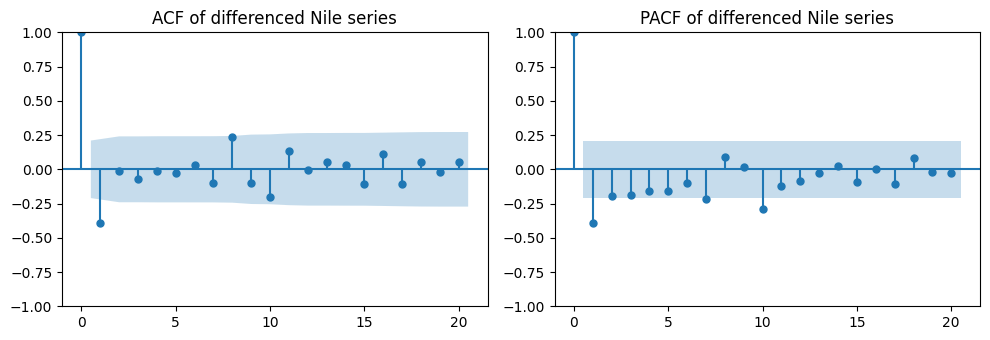

In [15]:
# ACF/PACF of the differenced Nile series help to motivate the choice of p and q
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
plot_acf(nile_train.diff().dropna(), ax=axes[0], lags=20)
plot_pacf(nile_train.diff().dropna(), ax=axes[1], lags=20)
axes[0].set_title("ACF of differenced Nile series")
axes[1].set_title("PACF of differenced Nile series")
plt.tight_layout()
plt.show()


ARIMA(1, 1, 1)
                               SARIMAX Results                                
Dep. Variable:                 volume   No. Observations:                   88
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -554.694
Date:                Wed, 17 Jun 2026   AIC                           1115.388
Time:                        12:47:43   BIC                           1122.786
Sample:                    01-01-1871   HQIC                          1118.367
                         - 01-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2617      0.135      1.936      0.053      -0.003       0.527
ma.L1         -0.8728      0.059    -14.909      0.000      -0.987      -0.758
sigma2      1.998e+04   2992.611     

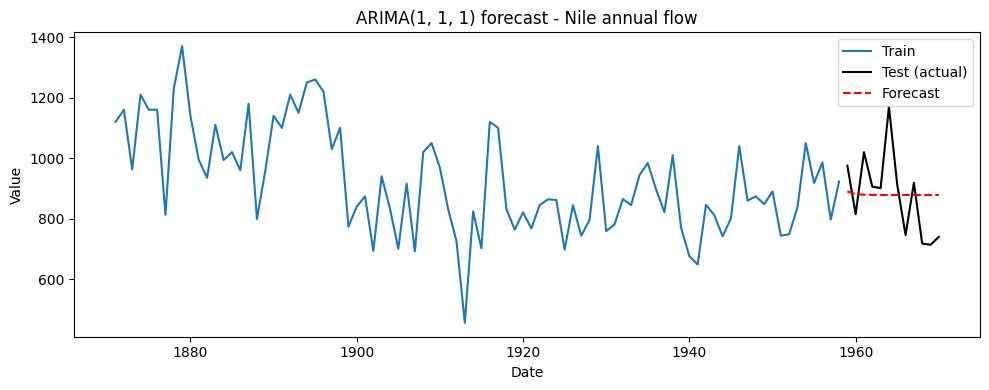

ARIMA(1, 1, 1)                         MAE=108.618  RMSE=132.274  MAPE=12.59%

ARIMA(2, 1, 2)
                               SARIMAX Results                                
Dep. Variable:                 volume   No. Observations:                   88
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -553.589
Date:                Wed, 17 Jun 2026   AIC                           1117.179
Time:                        12:47:43   BIC                           1129.508
Sample:                    01-01-1871   HQIC                          1122.144
                         - 01-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7016      0.139     -5.056      0.000      -0.974      -0.430
ar.L2          0.2984      0.136     

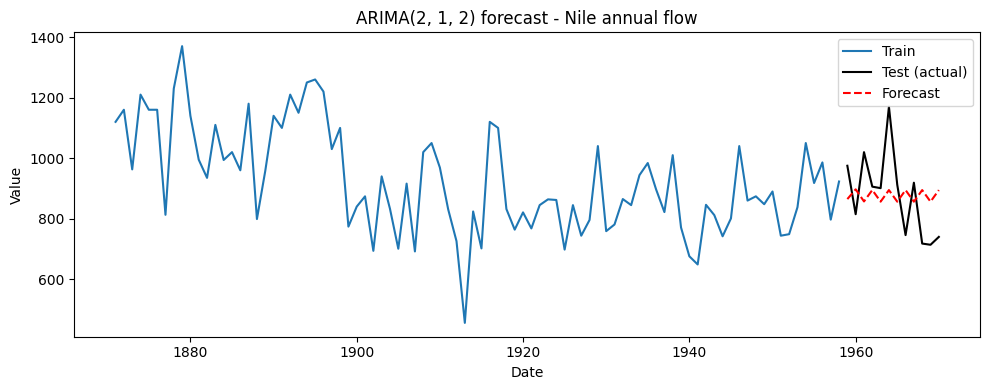

ARIMA(2, 1, 2)                         MAE=118.886  RMSE=137.782  MAPE=13.78%

ARIMA(3, 1, 1)
                               SARIMAX Results                                
Dep. Variable:                 volume   No. Observations:                   88
Model:                 ARIMA(3, 1, 1)   Log Likelihood                -554.443
Date:                Wed, 17 Jun 2026   AIC                           1118.885
Time:                        12:47:44   BIC                           1131.215
Sample:                    01-01-1871   HQIC                          1123.850
                         - 01-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2519      0.137      1.844      0.065      -0.016       0.520
ar.L2          0.0675      0.124     

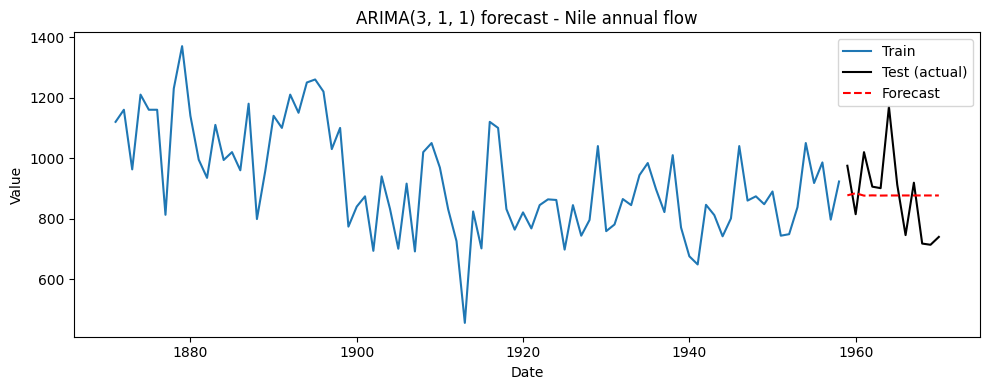

ARIMA(3, 1, 1)                         MAE=110.339  RMSE=133.239  MAPE=12.75%



In [16]:
# Fit and evaluate three ARIMA(p, d, q) configurations on the Nile data
arima_orders = [(1, 1, 1), (2, 1, 2), (3, 1, 1)]

for order in arima_orders:
    model_name = f"ARIMA{order}"

    # Fit the model on the training data
    model = ARIMA(nile_train, order=order)
    fitted = model.fit()

    # Print the model summary (coefficients, AIC/BIC, diagnostics)
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(fitted.summary())

    # Forecast over the test period
    forecast = fitted.get_forecast(steps=len(nile_test)).predicted_mean

    # Plot train / test / forecast
    plot_forecast(nile_train, nile_test, forecast,
                  title=f"{model_name} forecast - Nile annual flow")

    # Evaluate and store metrics for the final comparison table
    print_metrics(nile_test, forecast, model_name)
    record_result(model_name, str(order), "Nile (annual)", nile_test, forecast)
    print()


## 5. SARIMA model

```text
SARIMA(p, d, q)(P, D, Q, s)
```

- `(p, d, q)` — the same non-seasonal AR, differencing, and MA orders as in
  plain ARIMA.
- `(P, D, Q)` — the seasonal counterparts: seasonal AR order, seasonal
  differencing order, and seasonal MA order.
- `s` — the length of the seasonal period (e.g. `s=12` for monthly data
  with a yearly cycle).

`statsmodels` does not have a separate "SARIMA" class. Instead, **SARIMA is
implemented through the `SARIMAX` class**: when `exog` is not supplied,
`SARIMAX(order=..., seasonal_order=...)` is exactly a SARIMA model. We use
it that way in this section, and only add exogenous regressors in
Section 6.

We compare three configurations on the monthly CO2 series, which has both
a clear trend and a strong 12-month seasonal cycle.


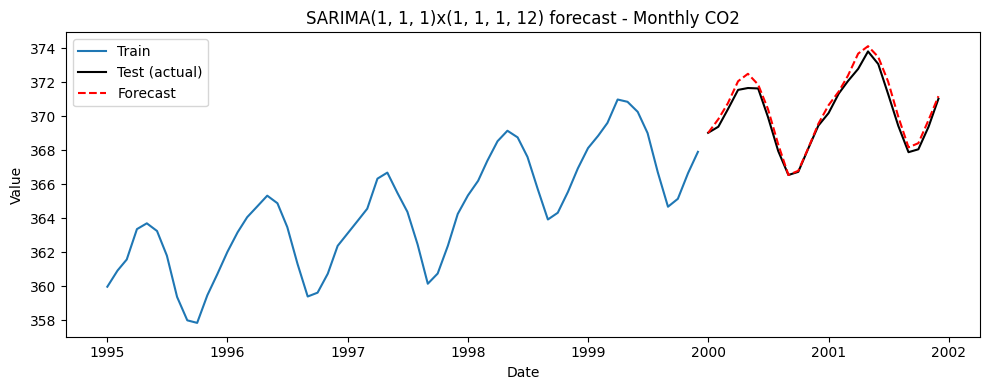

SARIMA(1, 1, 1)x(1, 1, 1, 12)          MAE=0.351  RMSE=0.425  MAPE=0.09%



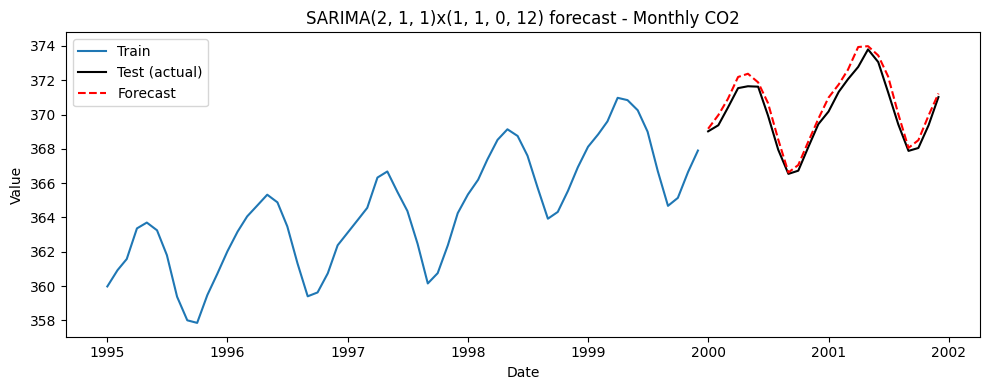

SARIMA(2, 1, 1)x(1, 1, 0, 12)          MAE=0.488  RMSE=0.554  MAPE=0.13%



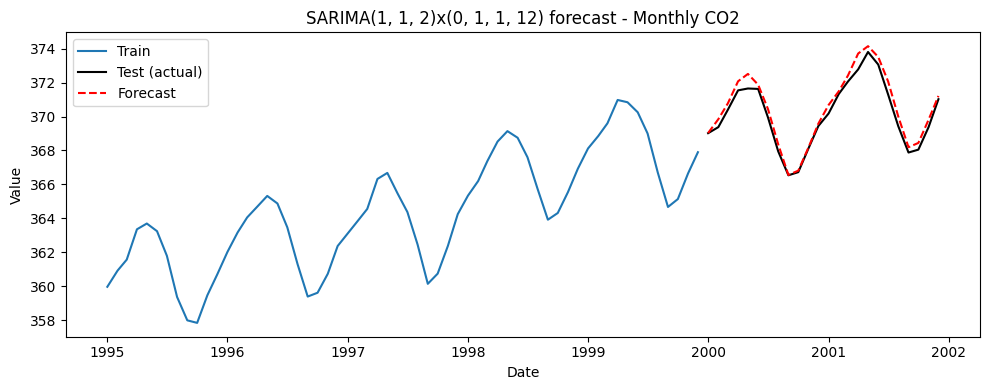

SARIMA(1, 1, 2)x(0, 1, 1, 12)          MAE=0.380  RMSE=0.451  MAPE=0.10%



In [17]:
# Fit and evaluate three SARIMA configurations (via SARIMAX without exog) on CO2 data
sarima_configs = [
    {"order": (1, 1, 1), "seasonal_order": (1, 1, 1, 12)},
    {"order": (2, 1, 1), "seasonal_order": (1, 1, 0, 12)},
    {"order": (1, 1, 2), "seasonal_order": (0, 1, 1, 12)},
]

for cfg in sarima_configs:
    order, seasonal_order = cfg["order"], cfg["seasonal_order"]
    model_name = f"SARIMA{order}x{seasonal_order}"

    # Fit the model (SARIMAX with no exog supplied = SARIMA)
    model = SARIMAX(
        co2_train, order=order, seasonal_order=seasonal_order,
        enforce_stationarity=False, enforce_invertibility=False,
    )
    fitted = model.fit(disp=False)

    # Forecast over the test period
    forecast = fitted.get_forecast(steps=len(co2_test)).predicted_mean

    # Plot the last 5 years of training data plus test/forecast
    plot_forecast(co2_train, co2_test, forecast,
                  title=f"{model_name} forecast - Monthly CO2", n_train_show=60)

    # Evaluate and store metrics
    print_metrics(co2_test, forecast, model_name)
    record_result(model_name, f"order={order}, seasonal_order={seasonal_order}",
                   "CO2 (monthly)", co2_test, forecast)
    print()


## 6. SARIMAX model with exogenous variables

```text
SARIMAX = SARIMA + external regressors
```

SARIMAX extends SARIMA by allowing one or more **exogenous variables**
(`exog`) -- external time series that are believed to help explain or
predict the target, but that are not modeled themselves. The target
variable here is quarterly **real GDP** (`realgdp`), and the exogenous
regressors are real consumption (`realcons`) and the M1 money supply
(`m1`), all from the `macrodata` dataset loaded in Section 2.3.

A crucial practical point: to forecast with SARIMAX, you need the
exogenous variables' values **for the forecast period as well**. In a real
deployment this means either (a) the exogenous variables are already known
in advance (e.g. a planned marketing budget, a calendar of holidays), or
(b) they are forecast independently and fed in as if they were known. In
this demonstration we simply use the real, historical test-period values
of `realcons` and `m1`, which is the standard way to evaluate SARIMAX's
accuracy in a backtest.

We compare two configurations: one with no seasonal component
(`seasonal_order=(0,0,0,0)`), and one with a quarterly seasonal component
(`seasonal_order=(1,0,1,4)`, since `s=4` for quarterly data).


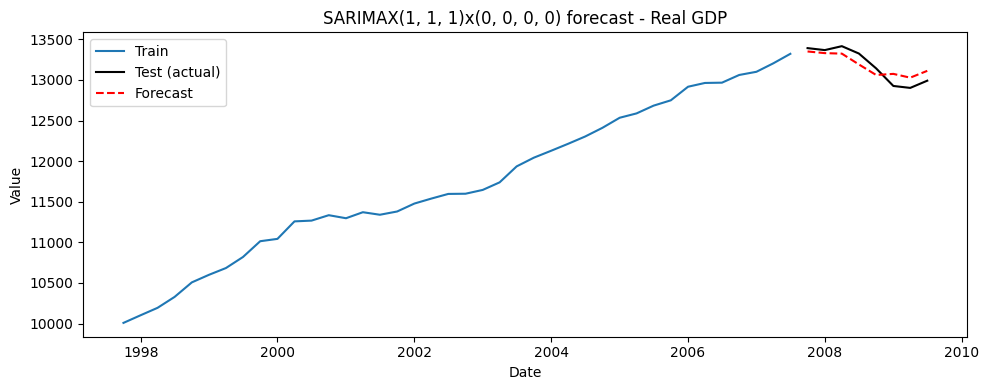

SARIMAX(1, 1, 1)x(0, 0, 0, 0)          MAE=97.705  RMSE=105.363  MAPE=0.74%



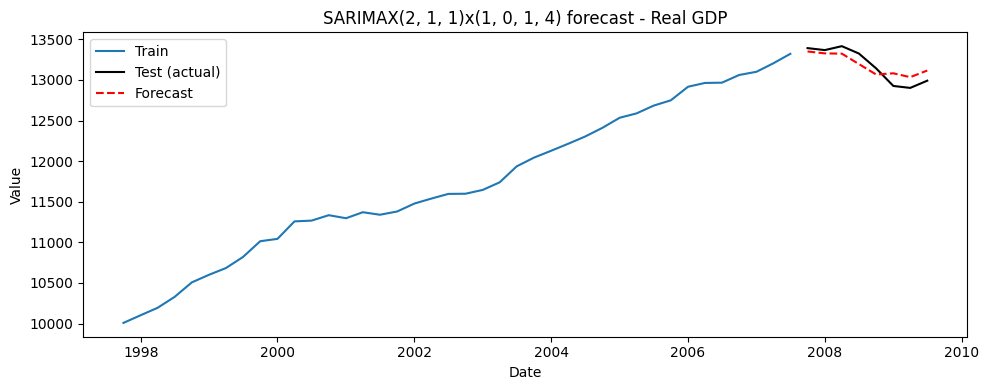

SARIMAX(2, 1, 1)x(1, 0, 1, 4)          MAE=98.994  RMSE=107.099  MAPE=0.75%



In [18]:
# Fit and evaluate two SARIMAX configurations with exogenous regressors on macrodata
sarimax_configs = [
    {"order": (1, 1, 1), "seasonal_order": (0, 0, 0, 0)},
    {"order": (2, 1, 1), "seasonal_order": (1, 0, 1, 4)},
]

for cfg in sarimax_configs:
    order, seasonal_order = cfg["order"], cfg["seasonal_order"]
    model_name = f"SARIMAX{order}x{seasonal_order}"

    # Fit the model with exogenous regressors on the training data
    model = SARIMAX(
        macro_train_y, exog=macro_train_x, order=order, seasonal_order=seasonal_order,
        enforce_stationarity=False, enforce_invertibility=False,
    )
    fitted = model.fit(disp=False)

    # Forecast over the test period using the *known* test-period exogenous values
    forecast = fitted.get_forecast(steps=len(macro_test_y), exog=macro_test_x).predicted_mean

    # Plot the last 10 years of training data plus test/forecast
    plot_forecast(macro_train_y, macro_test_y, forecast,
                  title=f"{model_name} forecast - Real GDP", n_train_show=40)

    # Evaluate and store metrics
    print_metrics(macro_test_y, forecast, model_name)
    record_result(model_name, f"order={order}, seasonal_order={seasonal_order}, exog=[realcons, m1]",
                   "Macrodata (realgdp)", macro_test_y, forecast)
    print()


**When is SARIMAX useful in practice?** Whenever a target series is driven,
at least in part, by other observable signals -- for example: sales
forecasting with promotional/marketing spend as exog, electricity demand
forecasting with temperature as exog, or (as here) GDP forecasting using
consumption and monetary indicators. If informative exogenous variables
are available (or can themselves be forecast reliably), SARIMAX can
substantially improve on a univariate SARIMA model that only sees the
target's own history.


## 7. Holt-Winters / Exponential Smoothing

Exponential smoothing methods forecast by taking a weighted average of past
observations, with weights that decay exponentially the further back in
time they go. There is a family of increasingly general versions:

- **Simple Exponential Smoothing (SES)** — `trend=None, seasonal=None`.
  Suitable for a roughly level (no trend, no seasonality) series; the
  forecast is a flat line at the (exponentially weighted) recent average.
- **Holt's linear trend method** — `trend="add"` (or `"mul"`),
  `seasonal=None`. Adds a second smoothing equation for the trend, so the
  forecast can increase or decrease linearly.
- **Holt-Winters method** — `trend=..., seasonal="add"` (or `"mul"`),
  `seasonal_periods=...`. Adds a third smoothing equation for seasonality,
  producing a forecast with both a trend and a repeating seasonal shape.
  Additive seasonality assumes the seasonal swing has constant absolute
  size; multiplicative seasonality assumes it scales with the series'
  level.

We demonstrate all three variants, plus a multiplicative Holt-Winters
model, on the same monthly CO2 series used for SARIMA, which makes the two
families of methods directly comparable in Section 8.


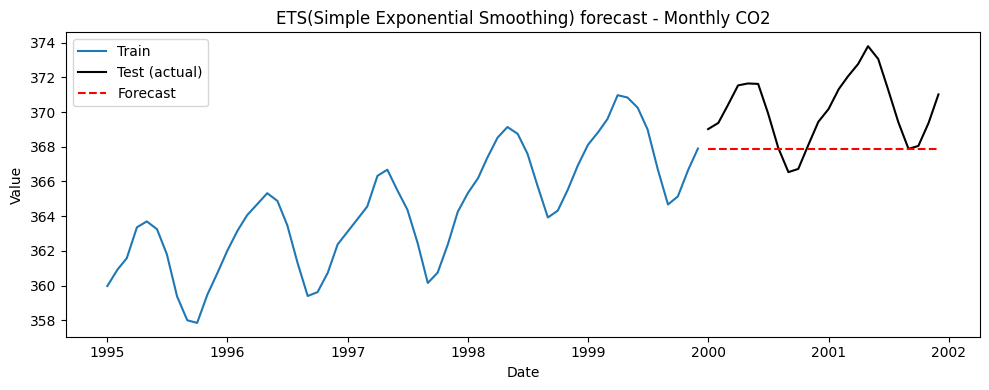

ETS(Simple Exponential Smoothing)      MAE=2.420  RMSE=2.929  MAPE=0.65%



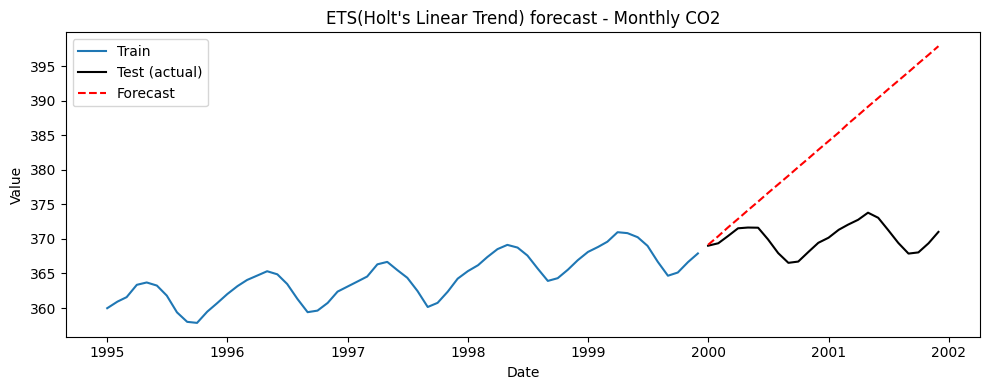

ETS(Holt's Linear Trend)               MAE=13.418  RMSE=15.969  MAPE=3.63%



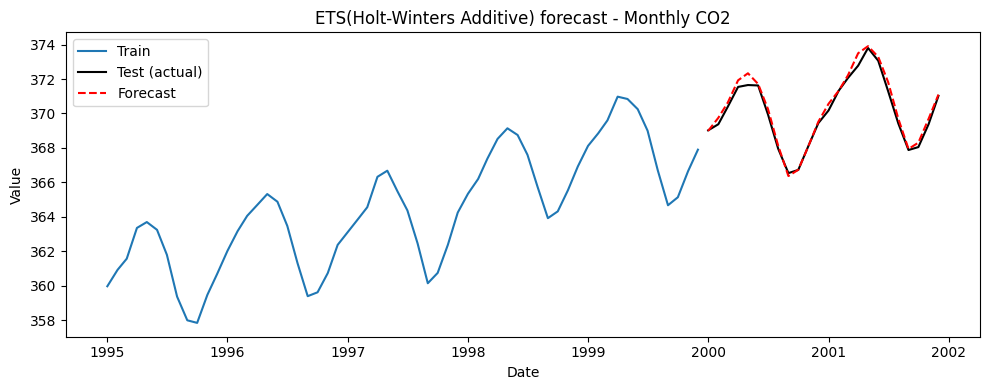

ETS(Holt-Winters Additive)             MAE=0.236  RMSE=0.307  MAPE=0.06%



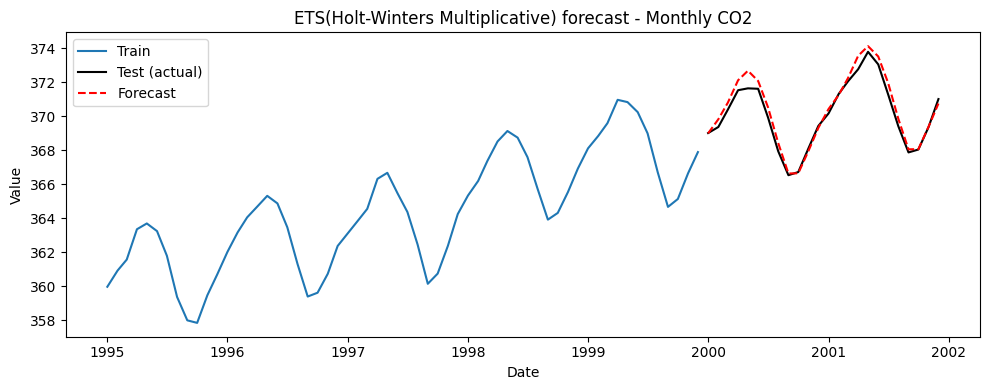

ETS(Holt-Winters Multiplicative)       MAE=0.341  RMSE=0.431  MAPE=0.09%



In [19]:
# Fit and evaluate four Exponential Smoothing configurations on CO2 data
ets_configs = [
    {"trend": None,  "seasonal": None,  "label": "Simple Exponential Smoothing"},
    {"trend": "add", "seasonal": None,  "label": "Holt's Linear Trend"},
    {"trend": "add", "seasonal": "add", "label": "Holt-Winters Additive"},
    {"trend": "mul", "seasonal": "mul", "label": "Holt-Winters Multiplicative"},
]

for cfg in ets_configs:
    trend, seasonal, label = cfg["trend"], cfg["seasonal"], cfg["label"]
    seasonal_periods = 12 if seasonal is not None else None
    model_name = f"ETS({label})"

    # Fit the model on the training data
    model = ExponentialSmoothing(
        co2_train, trend=trend, seasonal=seasonal, seasonal_periods=seasonal_periods,
    )
    fitted = model.fit()

    # Forecast over the test period
    forecast = fitted.forecast(len(co2_test))

    # Plot the last 5 years of training data plus test/forecast
    plot_forecast(co2_train, co2_test, forecast,
                  title=f"{model_name} forecast - Monthly CO2", n_train_show=60)

    # Evaluate and store metrics
    print_metrics(co2_test, forecast, model_name)
    record_result(model_name, f"trend={trend}, seasonal={seasonal}, seasonal_periods={seasonal_periods}",
                   "CO2 (monthly)", co2_test, forecast)
    print()


## 8. Model comparison

All metrics recorded by `record_result` throughout the notebook are now
collected into a single comparison table.


In [20]:
# Build the full comparison table from the results collected throughout the notebook
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(["Dataset", "RMSE"]).reset_index(drop=True)
comparison_df


,Dataset,Model,Parameters,MAE,RMSE,MAPE (%)
0,CO2 (monthly),ETS(Holt-Winters Additive),"trend=add, seasonal=add, seasonal_periods=12",0.236,0.307,0.06
1,CO2 (monthly),"SARIMA(1, 1, 1)x(1, 1, 1, 12)","order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)",0.351,0.425,0.09
2,CO2 (monthly),ETS(Holt-Winters Multiplicative),"trend=mul, seasonal=mul, seasonal_periods=12",0.341,0.431,0.09
3,CO2 (monthly),"SARIMA(1, 1, 2)x(0, 1, 1, 12)","order=(1, 1, 2), seasonal_order=(0, 1, 1, 12)",0.380,0.451,0.10
4,CO2 (monthly),"SARIMA(2, 1, 1)x(1, 1, 0, 12)","order=(2, 1, 1), seasonal_order=(1, 1, 0, 12)",0.488,0.554,0.13
5,CO2 (monthly),ETS(Simple Exponential Smoothing),"trend=None, seasonal=None, seasonal_periods=None",2.420,2.929,0.65
6,CO2 (monthly),ETS(Holt's Linear Trend),"trend=add, seasonal=None, seasonal_periods=None",13.418,15.969,3.63
7,Macrodata (realgdp),"SARIMAX(1, 1, 1)x(0, 0, 0, 0)","order=(1, 1, 1), seasonal_order=(0, 0, 0, 0), ...",97.705,105.363,0.74
8,Macrodata (realgdp),"SARIMAX(2, 1, 1)x(1, 0, 1, 4)","order=(2, 1, 1), seasonal_order=(1, 0, 1, 4), ...",98.994,107.099,0.75
9,Nile (annual),"ARIMA(1, 1, 1)","(1, 1, 1)",108.618,132.274,12.59


In [21]:
# Best (lowest-RMSE) model within each dataset
best_per_dataset = comparison_df.loc[comparison_df.groupby("Dataset")["RMSE"].idxmin()]
best_per_dataset


,Dataset,Model,Parameters,MAE,RMSE,MAPE (%)
0,CO2 (monthly),ETS(Holt-Winters Additive),"trend=add, seasonal=add, seasonal_periods=12",0.236,0.307,0.06
7,Macrodata (realgdp),"SARIMAX(1, 1, 1)x(0, 0, 0, 0)","order=(1, 1, 1), seasonal_order=(0, 0, 0, 0), ...",97.705,105.363,0.74
9,Nile (annual),"ARIMA(1, 1, 1)","(1, 1, 1)",108.618,132.274,12.59


**Discussion**

The cell above reports the actual numbers from this run (results will be
very similar, though not bit-for-bit identical, if you re-run the
notebook, since some optimizers use numerical routines with tiny
platform-dependent differences):

- *Which model performed best?* The best model differs **by dataset**,
  confirming that "best" is always relative to a specific series and
  horizon:
  - On **CO2 (monthly)**, **Holt-Winters Additive** was the most accurate
    (RMSE ≈ 0.31 ppm, MAPE ≈ 0.06%), narrowly ahead of the SARIMA models
    (best SARIMA RMSE ≈ 0.43 ppm).
  - On **Macrodata (realgdp)**, the simpler **SARIMAX(1,1,1)x(0,0,0,0)**
    slightly outperformed the seasonal **SARIMAX(2,1,1)x(1,0,1,4)**
    (RMSE ≈ 105 vs. 107), suggesting the extra seasonal terms were not
    needed for this quarterly series once `realcons` and `m1` are already
    included as regressors.
  - On **Nile (annual)**, the simplest configuration, **ARIMA(1,1,1)**,
    had the lowest RMSE (≈ 132), marginally ahead of ARIMA(3,1,1) (≈ 133)
    and ARIMA(2,1,2) (≈ 138).
- *Which model was simplest?* Simple Exponential Smoothing (no trend, no
  seasonal terms) is the simplest model in the notebook -- a single
  smoothing equation and one parameter to estimate. On the CO2 data it is
  clearly outperformed by the trend-and-seasonal models (RMSE ≈ 2.93 vs.
  ≈ 0.31-0.55 for the seasonal models), which illustrates the cost of
  ignoring structure that is visibly present in the data.
- *Which model handled seasonality best?* Only the SARIMA and seasonal
  Holt-Winters configurations explicitly model the 12-month cycle in the
  CO2 data, and the comparison table shows this clearly: every seasonal
  model (RMSE between 0.31 and 0.55) beats both non-seasonal ETS variants
  -- Simple Exponential Smoothing (RMSE ≈ 2.93) and Holt's linear trend
  (RMSE ≈ 15.97, MAPE ≈ 3.6%), which drifts increasingly out of phase with
  the real seasonal cycle the further it forecasts.
- *When should each model be preferred?*
  - **ARIMA** — non-seasonal series with trend/level changes and no useful
    external predictors (e.g. the Nile flow data), where this run shows
    that the simplest tested order, `(1,1,1)`, was sufficient.
  - **SARIMA** — series with a clear, fixed-period seasonal pattern but no
    external predictors (e.g. the CO2 data).
  - **SARIMAX** — like SARIMA, but when informative exogenous variables are
    available (or can be forecast) for the prediction horizon (e.g. GDP
    forecasting using consumption and money-supply data); note that adding
    unnecessary seasonal terms did not help in the macrodata example above.
  - **Holt-Winters** — a fast, robust classical baseline for trend and/or
    seasonal data; in this run its additive variant was in fact the single
    best model on the seasonal CO2 series, showing that it can be
    competitive with, or better than, SARIMA while being simpler to fit.


## 9. Conclusions

This notebook compared four classical forecasting approaches on three real
datasets with different characteristics (non-seasonal annual data,
seasonal monthly data, and quarterly data with exogenous predictors). The
main lessons are:

- **ARIMA** is useful for non-seasonal time series with trend or level
  changes that can be removed by differencing.
- **SARIMA** extends ARIMA with explicit seasonal AR, differencing, and MA
  terms, and is essential for series with a clear repeating cycle.
- **SARIMAX** adds external regressors on top of SARIMA, which can improve
  accuracy whenever informative exogenous data is available for the
  forecast horizon.
- **Holt-Winters / Exponential Smoothing** is a strong, simple, and fast
  classical baseline for trend-and-seasonal data, and is often competitive
  with, or even better than, the more parameter-heavy ARIMA-family models.
- The right model depends on the data's **stationarity**, whether
  **seasonality** is present, whether useful **external variables** are
  available, and the required **forecast horizon** -- there is no single
  model that is always best, which is why comparing several configurations
  (as done in Section 8) is good practice before deploying a forecasting
  model.
